In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import torch
from torchvision.io import decode_image
import torchvision.transforms.functional as F
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.segmentation import fcn_resnet50, FCN_ResNet50_Weights
from torchvision.utils import draw_bounding_boxes

In [2]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    _height = 6
    fig, axs = plt.subplots(figsize=(_height*len(imgs), _height), ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

In [3]:
decode_image(str(Path("data/archive/dataset/0.png")))

tensor([[[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [117, 106, 123,  ...,  64,  51,  55],
         [109,  85, 125,  ...,  50,  55,  48],
         [ 97, 137, 130,  ...,  45,  48,  62]],

        [[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [113, 102, 119,  ...,  63,  50,  54],
         [103,  79, 119,  ...,  49,  54,  47],
         [ 91, 131, 124,  ...,  44,  47,  61]],

        [[184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         [184, 184, 184,  ..., 191, 191, 191],
         ...,
         [114, 103, 120,  ...,  61,  48,  52],
         [105,  81, 121,  ...,  47,  52,  45],
         [ 93, 133, 126,  ...,  42,  45,  59]]], dtype=torch.uint8)

In [4]:
image_list = [
    decode_image(str(Path(f"data/kaggle-samples/{x}.png"))) for x in [2, 18, 255]
]

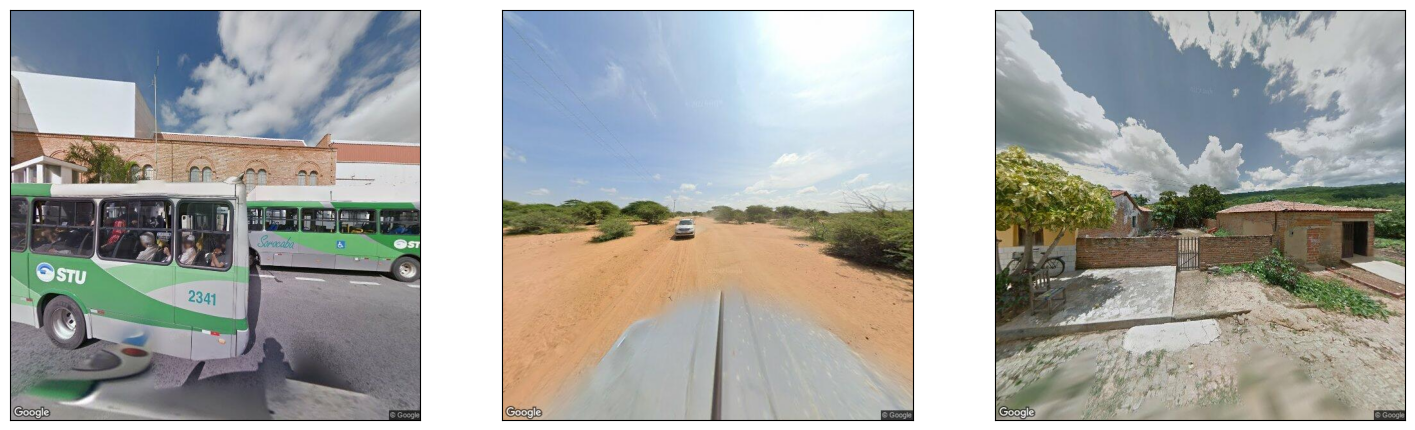

In [5]:
show(image_list)

In [6]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
transforms = weights.transforms()

### Object Detection Weights

https://docs.pytorch.org/vision/main/models.html#table-of-all-available-object-detection-weights

In [7]:
len(weights.meta["categories"])

91

In [8]:
weights.meta["categories"]

['__background__',
 'person',
 'bicycle',
 'car',
 'motorcycle',
 'airplane',
 'bus',
 'train',
 'truck',
 'boat',
 'traffic light',
 'fire hydrant',
 'N/A',
 'stop sign',
 'parking meter',
 'bench',
 'bird',
 'cat',
 'dog',
 'horse',
 'sheep',
 'cow',
 'elephant',
 'bear',
 'zebra',
 'giraffe',
 'N/A',
 'backpack',
 'umbrella',
 'N/A',
 'N/A',
 'handbag',
 'tie',
 'suitcase',
 'frisbee',
 'skis',
 'snowboard',
 'sports ball',
 'kite',
 'baseball bat',
 'baseball glove',
 'skateboard',
 'surfboard',
 'tennis racket',
 'bottle',
 'N/A',
 'wine glass',
 'cup',
 'fork',
 'knife',
 'spoon',
 'bowl',
 'banana',
 'apple',
 'sandwich',
 'orange',
 'broccoli',
 'carrot',
 'hot dog',
 'pizza',
 'donut',
 'cake',
 'chair',
 'couch',
 'potted plant',
 'bed',
 'N/A',
 'dining table',
 'N/A',
 'N/A',
 'toilet',
 'N/A',
 'tv',
 'laptop',
 'mouse',
 'remote',
 'keyboard',
 'cell phone',
 'microwave',
 'oven',
 'toaster',
 'sink',
 'refrigerator',
 'N/A',
 'book',
 'clock',
 'vase',
 'scissors',
 'ted

In [9]:
model = fasterrcnn_resnet50_fpn(weights=weights, progress=False)
model = model.eval()

In [14]:
images = [transforms(d) for d in image_list]
outputs = model(images)
print(outputs[0]['boxes'])

tensor([[370.7751, 282.3817, 640.0000, 419.0782],
        [  3.5643, 264.6360, 408.8775, 541.0180],
        [262.0772, 352.6993, 291.4592, 397.7032],
        [194.2547, 347.8468, 241.5027, 393.4224],
        [310.2563, 361.6261, 337.2448, 402.2215],
        [142.2792, 320.8899, 182.8963, 377.8744],
        [282.7533, 357.8289, 312.6397, 400.0706],
        [398.0951, 328.7790, 418.0642, 345.1296],
        [172.9819, 502.3378, 216.5121, 526.6054],
        [315.1974, 353.9208, 339.7855, 389.7536],
        [ 90.4433, 319.2050, 183.2062, 377.3288],
        [397.5656, 329.0843, 407.7492, 345.1355],
        [271.3117, 355.6964, 331.6042, 402.0404],
        [ 36.9500, 341.9146,  87.5235, 380.1817],
        [227.2215, 313.6038, 241.2255, 341.6263],
        [204.8827, 349.0009, 271.9507, 396.3867],
        [548.1051, 331.5201, 560.4835, 347.2223],
        [371.5222, 369.5980, 389.6468, 406.9739],
        [104.7047, 315.6453, 152.3463, 383.4993],
        [529.2029, 333.2223, 550.6528, 349.7834],


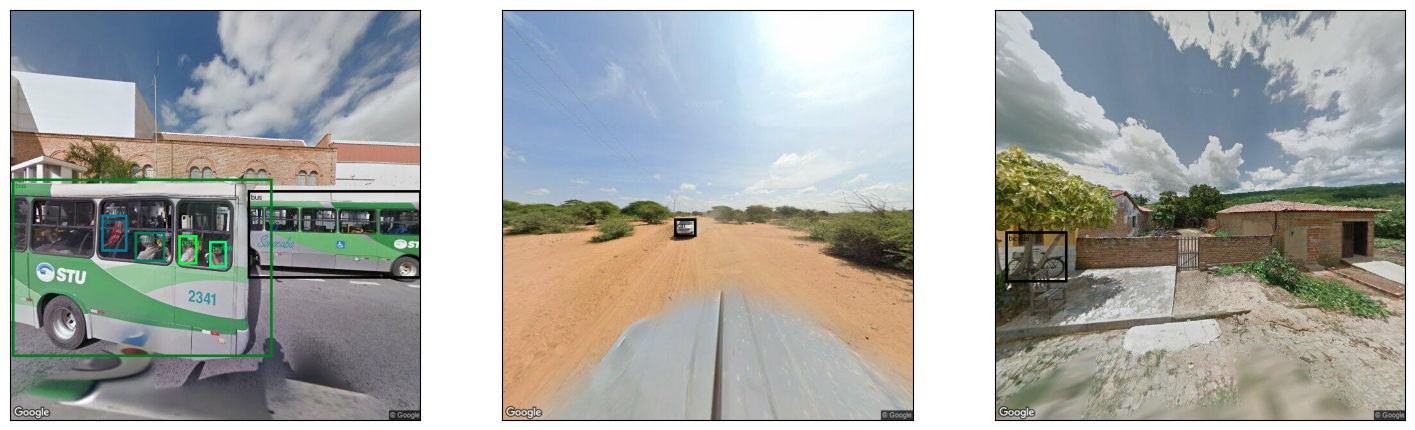

In [11]:
score_threshold = .8
imgs_with_boxes = [
    draw_bounding_boxes(img_int, boxes=output['boxes'][output['scores'] > score_threshold], width=4, 
                        labels=[weights.meta["categories"][_label] for _label in output['labels'][output['scores'] > score_threshold]]) for img_int, output in zip(image_list, outputs)
]
show(imgs_with_boxes)

In [12]:
output = outputs[0]
for _lable in output['labels'][output['scores'] > score_threshold]:
    print(weights.meta["categories"][_lable])

bus
bus
person
person
person
person


In [13]:
def obj_detect(image, model, score_threshold=0.8):
    """
    Function that combines a few of the above steps to
    quickly and easily run the object detection model and
    visualize the outputs.
    """
    image = [transforms(image)]
    outputs = model(image)
    output = outputs[0]
    labels = [weights.meta["categories"][_label] for _label in output['labels'][output['scores'] > score_threshold]]
    img_with_boxes = draw_bounding_boxes(image[0], boxes=output['boxes'][output['scores'] > score_threshold], labels=labels, width=4)
    show(img_with_boxes)
    return labels
    

## Where to Get Street View Imagery

One source of street view imagery is Mapillary!

For example, I obtained this image from the University of Texas at Dallas: https://www.mapillary.com/app/?pKey=561334792755861 The image can be viewed below:



<iframe width="640" height="480" src="https://www.mapillary.com/embed?map_style=Mapillary%20light&image_key=561334792755861&x=0.49999999999999933&y=0.5&style=photo" frameborder="0"></iframe>

In [168]:
UTD_image = decode_image(str(Path(f"data/UTD.jpeg")))
UTD_image

tensor([[[ 73,  87, 131,  ..., 253, 253, 253],
         [ 64,  79, 126,  ..., 253, 253, 253],
         [ 87,  88, 103,  ..., 254, 254, 254],
         ...,
         [116, 115, 116,  ...,  94,  96,  98],
         [117, 115, 116,  ...,  94,  97,  99],
         [117, 114, 115,  ...,  94,  97, 100]],

        [[ 70,  84, 128,  ..., 254, 254, 254],
         [ 61,  76, 123,  ..., 254, 254, 254],
         [ 84,  85, 100,  ..., 255, 255, 255],
         ...,
         [118, 117, 118,  ...,  95,  97,  99],
         [119, 117, 118,  ...,  95,  98, 100],
         [119, 116, 117,  ...,  95,  98, 101]],

        [[ 65,  79, 123,  ..., 249, 249, 249],
         [ 56,  71, 118,  ..., 249, 249, 249],
         [ 79,  80,  95,  ..., 250, 250, 250],
         ...,
         [115, 114, 115,  ...,  97,  99, 101],
         [116, 114, 115,  ...,  97, 100, 102],
         [116, 113, 114,  ...,  97, 100, 103]]], dtype=torch.uint8)

['stop sign', 'car', 'car']

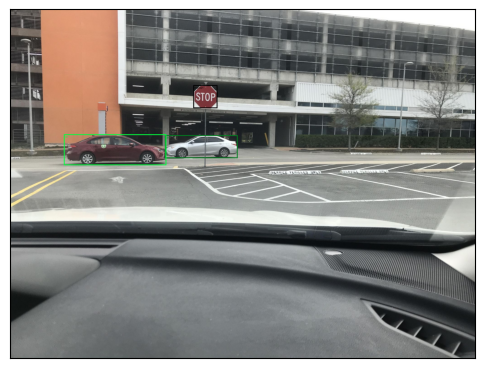

In [169]:
obj_detect(UTD_image, model)